---
date: "2026-07-18"
date-modified: last-modified
format:
  html:
    toc: true
---

# Transformations and Convolutions

In probability theory, we frequently need to derive the distribution of a new random variable $Y = g(X)$ formed by applying a mathematical transformation to a known continuous random variable $X$, or the distribution of a sum $T = X + Y$ of two independent random variables (**convolutions**). This note establishes the rigorous change of variables formulas in one and multi-dimensional spaces and derives the convolution identities for discrete and continuous distributions.


## 1\. Transformations of 1D Continuous Random Variables

When a continuous [random variable](random-variables.ipynb) $X$ with a known probability density function (PDF) $f_X(x)$ is mapped through a differentiable function $Y = g(X)$, how do we find the PDF $f_Y(y)$? Simply plugging $g^{-1}(y)$ into $f_X$ is incorrect because probability mass is conserved over intervals ($P(x \le X \le x + dx) = P(y \le Y \le y + dy)$), meaning the density must be scaled by the rate at which the interval stretches or compresses.

::: {#thm-1d-transformation}
## Change of Variables (1D Strictly Monotonic Transformation)
Let $X$ be a [continuous random variable](continuous-rv.ipynb) with PDF $f_X(x)$, and let $Y = g(X)$, where $g$ is differentiable and strictly monotonic (either strictly increasing or strictly decreasing) on the support of $X$. Then the probability density function of $Y$ is given by:

$$
f_Y(y) = f_X(g^{-1}(y)) \left| \frac{dx}{dy} \right| \quad \text{where } x = g^{-1}(y)
$$

By the Inverse Function Theorem, the derivative factor can also be written in terms of $\frac{dy}{dx}$:

$$
\frac{dx}{dy} = \left(\frac{dy}{dx}\right)^{-1}
$$
:::

::: {.callout-tip collapse="true"}
## Proof of 1D Change of Variables (Strictly Increasing Case)
Suppose $g$ is strictly increasing. Then the cumulative distribution function (CDF) of $Y$, denoted $F_Y(y)$, relates directly to the CDF of $X$, $F_X(x)$, via:

$$
\begin{aligned}
F_Y(y) &= P(Y \le y) \\
&= P(g(X) \le y) \\
&= P(X \le g^{-1}(y)) \\
&= F_X(g^{-1}(y))
\end{aligned}
$$

To obtain the probability density function $f_Y(y)$, we differentiate the CDF $F_Y(y)$ with respect to $y$. Applying the Chain Rule gives:

$$
\begin{aligned}
f_Y(y) &= \frac{d}{dy} F_Y(y) \\
&= \frac{d}{dy} F_X(g^{-1}(y)) \\
&= f_X(g^{-1}(y)) \frac{d}{dy} g^{-1}(y) \\
&= f_X(x) \frac{dx}{dy}
\end{aligned}
$$

Since $g$ is strictly increasing, its inverse $g^{-1}(y)$ is also strictly increasing, so $\frac{dx}{dy} > 0$. Thus $\frac{dx}{dy} = \left|\frac{dx}{dy}\right|$. $\blacksquare$
:::

::: {.callout-note}
## Intuition: Conservation of Probability Mass over Infinitesimal Intervals
Consider a tiny interval around $x$ of width $dx$. Under the mapping $y = g(x)$, this interval maps to a tiny interval around $y$ of width $dy \approx \left|\frac{dy}{dx}\right| dx$. Because probability is conserved, the chance that $X$ falls in $[x, x+dx]$ must equal the chance that $Y$ falls in $[y, y+dy]$:

$$
f_X(x) \, dx \approx f_Y(y) \, dy \implies f_Y(y) = f_X(x) \left| \frac{dx}{dy} \right|
$$

The absolute value ensures that density remains strictly non-negative even when $g(x)$ is decreasing (where $dx$ and $dy$ have opposite signs).
:::

::: {.callout-warning}
## Where did we use the strictly increasing criterion?
In the proof above, the transition from $P(g(X) \le y)$ to $P(X \le g^{-1}(y))$ **relies entirely on $g$ being strictly increasing** so that applying $g^{-1}$ preserves the direction of the inequality!
If $g$ were **strictly decreasing**, applying $g^{-1}$ to both sides reverses the inequality sign:

$$
g(X) \le y \iff X \ge g^{-1}(y)
$$

In that decreasing case, the CDF becomes:

$$
F_Y(y) = P(X \ge g^{-1}(y)) = 1 - F_X(g^{-1}(y))
$$

Differentiating with respect to $y$ yields:

$$
f_Y(y) = \frac{d}{dy}[1 - F_X(g^{-1}(y))] = -f_X(g^{-1}(y)) \frac{dx}{dy}
$$

Because $g$ is decreasing, $\frac{dx}{dy} < 0$, so $-\frac{dx}{dy} = \left|\frac{dx}{dy}\right|$. Combining both increasing and decreasing cases proves that the absolute value $\left|\frac{dx}{dy}\right|$ universally handles any strict monotonicity.
:::


### 1.1\. Example: The Log-Normal Distribution

**Example (Log-Normal Transformation):**
Let $Z \sim \mathcal{N}(0, 1)$ follow a [Standard Normal distribution](normal-distribution.ipynb), and define the transformed random variable $Y = e^Z$. Derive the probability density function $f_Y(y)$.

::: {.callout-warning}
## Terminology Trap: Log-Normal vs. Normal
A **Log-Normal** random variable $Y$ is **not** normally distributed! The name signifies that taking the *logarithm* of $Y$ yields a normal random variable: $\ln(Y) = Z \sim \mathcal{N}(0, 1)$. While the normal distribution is symmetric and supported on $(-\infty, \infty)$, the Log-Normal distribution is strictly positive ($Y > 0$) and heavily right-skewed.
:::

::: {.callout-tip collapse="true"}
## Solution: Deriving the Log-Normal PDF
We apply the 1D change of variables theorem.
Let $y = g(z) = e^z$. Since the exponential function is strictly increasing, we invert it for $y > 0$:

$$
z = g^{-1}(y) = \ln(y)
$$

We compute the derivative of the inverse transformation:

$$
\frac{dz}{dy} = \frac{d}{dy}(\ln y) = \frac{1}{y}
$$

Alternatively, since $\frac{dy}{dz} = e^z = y$, we have $\frac{dz}{dy} = \left(\frac{dy}{dz}\right)^{-1} = \frac{1}{y}$.
The known PDF of the standard normal variable $Z$ is:

$$
f_Z(z) = \frac{1}{\sqrt{2\pi}} e^{-z^2 / 2}, \quad z \in (-\infty, \infty)
$$

Substituting $z = \ln(y)$ and multiplying by the Jacobian factor $\left|\frac{dz}{dy}\right| = \frac{1}{y}$:

$$
\begin{aligned}
f_Y(y) &= f_Z(\ln y) \left| \frac{dz}{dy} \right| \\
&= \frac{1}{\sqrt{2\pi}} e^{-(\ln y)^2 / 2} \cdot \frac{1}{y} \\
&= \frac{1}{y\sqrt{2\pi}} \exp\left( -\frac{(\ln y)^2}{2} \right), \quad \text{for } y > 0
\end{aligned}
$$

For $y \le 0$, the density is zero ($f_Y(y) = 0$). $\blacksquare$
:::

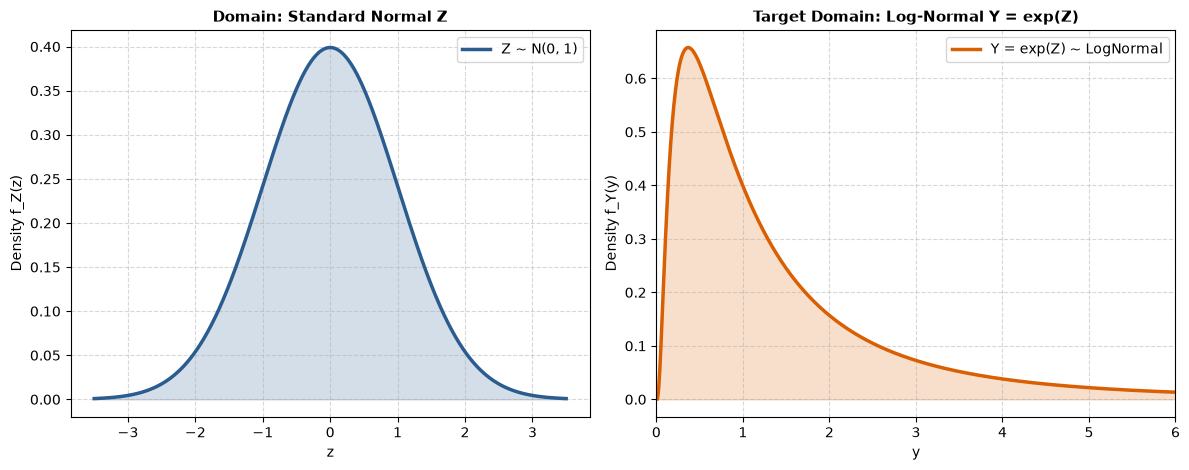

In [1]:
#| label: fig-lognormal-transformation
#| fig-cap: "Visualizing the 1D change of variables: mapping the symmetric Standard Normal distribution Z ~ N(0, 1) through the exponential function Y = exp(Z) produces the strictly positive, right-skewed Log-Normal density."

import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-3.5, 3.5, 1000)
f_z = (1 / np.sqrt(2 * np.pi)) * np.exp(-z**2 / 2)

y = np.linspace(0.01, 6.0, 1000)
f_y = (1 / (y * np.sqrt(2 * np.pi))) * np.exp(-(np.log(y))**2 / 2)

fig, axs = plt.subplots(1, 2, figsize=(12, 4.8))

# Subplot 1: Standard Normal Z
axs[0].plot(z, f_z, color='#2b5c8f', linewidth=2.5, label='Z ~ N(0, 1)')
axs[0].fill_between(z, f_z, alpha=0.2, color='#2b5c8f')
axs[0].set_title('Domain: Standard Normal Z', fontsize=11, fontweight='bold')
axs[0].set_xlabel('z')
axs[0].set_ylabel('Density f_Z(z)')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legend(loc='upper right')

# Subplot 2: Log-Normal Y = exp(Z)
axs[1].plot(y, f_y, color='#d95f02', linewidth=2.5, label='Y = exp(Z) ~ LogNormal')
axs[1].fill_between(y, f_y, alpha=0.2, color='#d95f02')
axs[1].set_title('Target Domain: Log-Normal Y = exp(Z)', fontsize=11, fontweight='bold')
axs[1].set_xlabel('y')
axs[1].set_ylabel('Density f_Y(y)')
axs[1].set_xlim(0, 6)
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


## 2\. Transformations in Multi-Dimensional Space ($\mathbb{R}^n$)

When generalizing from a single random variable to a vector of continuous random variables $\vec{X} = (X_1, X_2, \dots, X_n)$ transformed into $\vec{Y} = (Y_1, Y_2, \dots, Y_n)$ via a multivariate mapping $\vec{Y} = g(\vec{X})$, the scalar stretching factor $\left|\frac{dx}{dy}\right|$ is replaced by the **absolute value of the determinant of the Jacobian matrix**.

::: {#thm-multivariate-transformation}
## Multivariate Change of Variables (Jacobian Theorem)
Let $\vec{X} = (X_1, \dots, X_n)$ be a vector of continuous random variables with [joint PDF](joint-distribution.ipynb) $f_{\vec{X}}(\vec{x})$. Let $g: \mathbb{R}^n \to \mathbb{R}^n$ be an invertible, continuously differentiable transformation mapping $\vec{x}$ to $\vec{y} = g(\vec{x})$. Then the joint PDF of $\vec{Y} = g(\vec{X})$ is given by:

$$
f_{\vec{Y}}(\vec{y}) = f_{\vec{X}}(g^{-1}(\vec{y})) \left| \det\left(\frac{\partial \vec{x}}{\partial \vec{y}}\right) \right|
$$

where $\frac{\partial \vec{x}}{\partial \vec{y}}$ is the **Jacobian matrix** of first-order partial derivatives of the inverse transformation $\vec{x} = g^{-1}(\vec{y})$:

$$
\frac{\partial \vec{x}}{\partial \vec{y}} = \begin{pmatrix}
\frac{\partial x_1}{\partial y_1} & \frac{\partial x_1}{\partial y_2} & \cdots & \frac{\partial x_1}{\partial y_n} \\
\frac{\partial x_2}{\partial y_1} & \frac{\partial x_2}{\partial y_2} & \cdots & \frac{\partial x_2}{\partial y_n} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial x_n}{\partial y_1} & \frac{\partial x_n}{\partial y_2} & \cdots & \frac{\partial x_n}{\partial y_n}
\end{pmatrix}
$$

The factor $\left| \det\left(\frac{\partial \vec{x}}{\partial \vec{y}}\right) \right|$ represents the absolute value of the determinant of this $n \times n$ matrix.
:::

::: {.callout-note}
## Intuition: The Jacobian Determinant as a Volume Scaling Factor
In linear algebra and multivariable calculus, the determinant of a matrix measures how much linear transformations expand or contract $n$-dimensional volumes (parallelepipeds). Under a locally linear transformation $\vec{Y} = g(\vec{X})$, an infinitesimal volume element $d\vec{x} = dx_1 dx_2 \cdots dx_n$ in the domain transforms into an infinitesimal volume element $d\vec{y} = dy_1 dy_2 \cdots dy_n$ in the range, related by:

$$
d\vec{y} = \left| \det\left(\frac{\partial \vec{y}}{\partial \vec{x}}\right) \right| d\vec{x} \implies d\vec{x} = \left| \det\left(\frac{\partial \vec{x}}{\partial \vec{y}}\right) \right| d\vec{y}
$$

Equating the conserved probability mass over the infinitesimal volume element ($f_{\vec{X}}(\vec{x}) d\vec{x} = f_{\vec{Y}}(\vec{y}) d\vec{y}$) immediately yields the multivariate Jacobian formula.
:::


## 3\. Convolutions: Sums of Independent Random Variables

A foundational operation in probability is finding the distribution of the sum $T = X + Y$ of two [independent random variables](independence-of-rvs.ipynb) $X$ and $Y$. This sum operation is called a **convolution**.

::: {#def-convolution}
## Convolution of Probability Distributions
Let $X$ and $Y$ be independent random variables, and let $T = X + Y$.

1. **Discrete Case:** If $X$ and $Y$ are discrete with probability mass functions (PMFs) $P(X = x)$ and $P(Y = y)$, the PMF of $T$ is given by the discrete convolution sum:
   $$
   P(T = t) = \sum_{x} P(X = x) P(Y = t - x)
   $$

2. **Continuous Case:** If $X$ and $Y$ are continuous with probability density functions (PDFs) $f_X(x)$ and $f_Y(y)$, the PDF of $T$ is given by the continuous convolution integral:
   $$
   f_T(t) = (f_X * f_Y)(t) = \int_{-\infty}^\infty f_X(x) f_Y(t - x) \, dx
   $$
:::

::: {.callout-tip collapse="true"}
## Proof of Continuous Convolution Formula via CDF and Total Probability
We derive $f_T(t)$ by first expressing the cumulative distribution function $F_T(t) = P(T \le t) = P(X + Y \le t)$ using the continuous Law of Total Probability conditioning on the value of $X$:

$$
\begin{aligned}
F_T(t) &= P(X + Y \le t) \\
&= \int_{-\infty}^\infty P(X + Y \le t \mid X = x) f_X(x) \, dx \\
&= \int_{-\infty}^\infty P(x + Y \le t \mid X = x) f_X(x) \, dx \\
&= \int_{-\infty}^\infty P(Y \le t - x \mid X = x) f_X(x) \, dx
\end{aligned}
$$

Because $X$ and $Y$ are **independent**, conditioning on $X = x$ provides no information about $Y$, so $P(Y \le t - x \mid X = x) = P(Y \le t - x) = F_Y(t - x)$. Thus:

$$
F_T(t) = \int_{-\infty}^\infty F_Y(t - x) f_X(x) \, dx
$$

To obtain the probability density function $f_T(t)$, we take the derivative with respect to $t$. By Leibniz's integral rule, we differentiate inside the integral:

$$
\begin{aligned}
f_T(t) &= \frac{d}{dt} F_T(t) \\
&= \frac{d}{dt} \int_{-\infty}^\infty F_Y(t - x) f_X(x) \, dx \\
&= \int_{-\infty}^\infty \left[ \frac{\partial}{\partial t} F_Y(t - x) \right] f_X(x) \, dx \\
&= \int_{-\infty}^\infty f_Y(t - x) f_X(x) \, dx
\end{aligned}
$$

Since $f_X(x)f_Y(t-x) = f_Y(t-x)f_X(x)$, the convolution integral is commutative ($f_X * f_Y = f_Y * f_X$). $\blacksquare$
:::

::: {.callout-note}
## Intuition: Blending Two Distributions across All Split Configurations
To achieve a total sum of $T = t$, if variable $X$ takes on the specific value $x$, variable $Y$ must simultaneously take on the remaining deficit $t - x$. Because $X$ and $Y$ are independent, the joint density of this specific pair of outcomes is simply the product of their individual densities: $f_X(x) \cdot f_Y(t - x)$. Integrating over all possible values of $x \in (-\infty, \infty)$ sums up the probability density across every conceivable way $X$ and $Y$ can combine to produce the total $t$.
:::


### 3.1\. Example: Convolution of Two Independent Uniform Distributions

**Example (Irwin-Hall Distribution for $n=2$):**
Let $X, Y \stackrel{\text{i.i.d.}}{\sim} \text{Unif}(0, 1)$ be independent Uniform random variables on the interval $[0, 1]$. Derive the exact probability density function of their sum $T = X + Y$.

::: {.callout-tip collapse="true"}
## Solution: Deriving the Triangular Convolution Density
The individual PDFs are $f_X(u) = f_Y(u) = 1$ for $0 \le u \le 1$, and $0$ otherwise.
Using the continuous convolution integral:

$$
f_T(t) = \int_{-\infty}^\infty f_X(x) f_Y(t - x) \, dx
$$

The integrand $f_X(x) f_Y(t - x) = 1 \cdot 1 = 1$ is non-zero if and only if **both** of the following conditions hold simultaneously:

1. $0 \le x \le 1$ (from $f_X(x) = 1$)
2. $0 \le t - x \le 1 \implies t - 1 \le x \le t$ (from $f_Y(t - x) = 1$)

Therefore, for any fixed $t$, the integration domain over $x$ is the intersection $[0, 1] \cap [t - 1, t]$. We analyze two cases based on where $t$ falls in the support $(0, 2)$:

**Case 1: $0 \le t \le 1$**
When $t \in [0, 1]$, the lower bound $t - 1 \le 0$, so the intersection $[0, 1] \cap [t - 1, t]$ simplifies to $[0, t]$:

$$
f_T(t) = \int_0^t 1 \, dx = [x]_0^t = t
$$

**Case 2: $1 < t \le 2$**
When $t \in (1, 2]$, the upper bound $t > 1$, so the intersection $[0, 1] \cap [t - 1, t]$ simplifies to $[t - 1, 1]$:

$$
f_T(t) = \int_{t-1}^1 1 \, dx = [x]_{t-1}^1 = 1 - (t - 1) = 2 - t
$$

Combining both cases yields the piecewise **triangular density** (Irwin-Hall distribution):

$$
f_T(t) = \begin{cases}
t & \text{if } 0 \le t \le 1 \\
2 - t & \text{if } 1 < t \le 2 \\
0 & \text{otherwise}
\end{cases}
$$

$\blacksquare$
:::

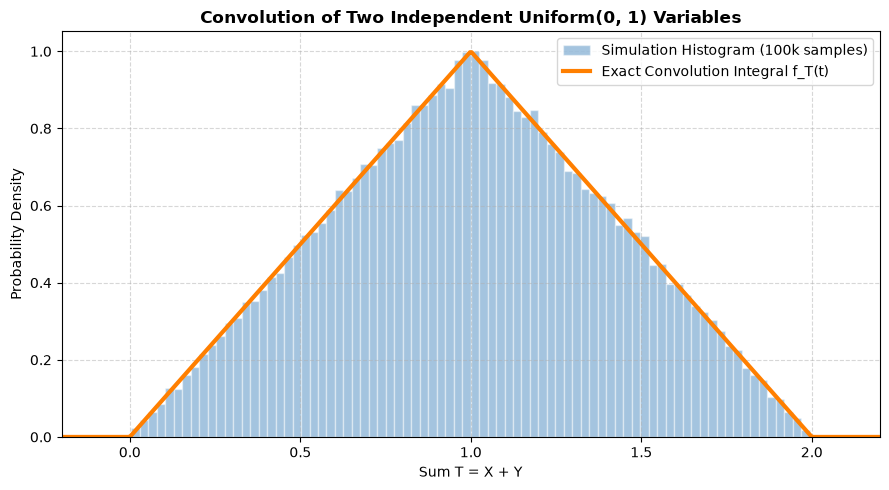

In [2]:
#| label: fig-uniform-convolution
#| fig-cap: "Convolving two independent flat Uniform(0, 1) distributions produces the triangular Irwin-Hall distribution on [0, 2]. Notice the perfect agreement between the Monte Carlo simulation histogram (blue bars) and our analytical piecewise convolution formula (orange line)."

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_samples = 100000

x_unif = np.random.uniform(0, 1, n_samples)
y_unif = np.random.uniform(0, 1, n_samples)
t_sum = x_unif + y_unif

t_grid = np.linspace(-0.2, 2.2, 500)
f_exact = np.piecewise(t_grid, 
                       [ (t_grid >= 0) & (t_grid <= 1), (t_grid > 1) & (t_grid <= 2) ],
                       [ lambda t: t, lambda t: 2 - t, 0 ])

plt.figure(figsize=(9, 5))
plt.hist(t_sum, bins=80, density=True, alpha=0.45, color='#377eb8', edgecolor='white', label='Simulation Histogram (100k samples)')
plt.plot(t_grid, f_exact, color='#ff7f00', linewidth=3, label='Exact Convolution Integral f_T(t)')
plt.title('Convolution of Two Independent Uniform(0, 1) Variables', fontsize=12, fontweight='bold')
plt.xlabel('Sum T = X + Y')
plt.ylabel('Probability Density')
plt.xlim(-0.2, 2.2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

> **References & Acknowledgments:**
> Notes adapted from Stat 110: Probability (Lecture 22: Transformations and Convolutions) by Joe Blitzstein ([YouTube Reference](https://www.youtube.com/watch?v=yXwPUAIvFyg&list=PL2SOU6wwxB0uwwH80KTQ6ht66KWxbzTIo&index=22)).